# W08 超参调优与 RL Baselines3 Zoo

> 阶段一（SB3 算法基础）· 第 8 周
> 前置：W05（PPO 超参初识）、W07（训练工程化）

## 学习目标

完成本 notebook 后，你应该能够：

1. 说出 PPO 关键超参数的含义与相互作用，知道哪些值得调、哪些基本不动；
2. 解释网格搜索 / 随机搜索 / 贝叶斯优化（TPE）的差异与适用场景；
3. 用 Optuna 定义搜索空间与目标函数，完成一次小规模 PPO 自动调参；
4. 从 RL Baselines3 Zoo 找到并复用官方调好的超参数，与默认超参做对比实验；
5. 建立调参实验的基本规范：固定评估协议、记录搜索历史、区分「调参集」与「最终评估」。


## 1. 超参数：RL 的「隐形代码」

 supervised learning 里超参调不好通常只是收敛慢一点；RL 里超参直接决定**学不学得会**。同一个 PPO，`learning_rate` 差 10 倍，一个收敛一个发散。

### PPO 关键超参速查表

| 超参 | 含义 | 调大 / 调小的典型效果 |
|------|------|----------------------|
| `learning_rate` | 优化器步长 | 太大：KL 爆炸、回报震荡；太小：学不动 |
| `n_steps` | 每环境 rollout 长度 | 大：batch 大、梯度稳但更新慢；小：更新频繁但噪声大 |
| `batch_size` | 每次 SGD 的 minibatch | 应整除 `n_steps × n_envs`；大 batch 配大 lr |
| `n_epochs` | 每批数据重复训练轮数 | 大：样本利用率高，但容易偏离旧策略太远 |
| `gamma` | 折扣因子 | 接近 1：看重长期回报（稀疏奖励任务）；小：短视但方差小 |
| `gae_lambda` | GAE 偏差-方差权衡 | 1：低偏差高方差；0：高偏差低方差 |
| `clip_range` | PPO 截断范围 $\epsilon$ | 大：允许更大策略更新，风险更高 |
| `ent_coef` | 熵奖励系数 | >0 鼓励探索；稀疏奖励任务常需要 |

这些超参**互相耦合**（比如 `n_steps × n_envs / batch_size` 决定每次更新的 minibatch 数），所以单变量逐一调往往找不到好组合——这就是自动调参存在的意义。

### 三种搜索策略

设每个超参取 $k$ 个候选值、共 $d$ 个超参：

- **网格搜索**：试遍全部 $k^d$ 个组合。$d=5, k=5$ 就是 3125 组——RL 每组要训练几分钟，完全不可行。
- **随机搜索**：每次独立随机采样 $B$ 组。Bergstra & Bengio (2012) 证明：当只有少数超参真正重要时（RL 恰恰如此），随机搜索的效率远优于网格。
- **贝叶斯优化 / TPE**：根据已有试验结果建模「哪片区域更可能好」，**有方向地**选下一组。Optuna 默认用的 TPE（Tree-structured Parzen Estimator）就是这一类。


## 2. Optuna 实战：小规模 PPO 调参

Optuna 的核心抽象就两个：

- **objective(trial)**：给定一组超参，返回一个标量分数（越高越好，默认 maximize 方向由 study 决定）；
- **study**：管理整个搜索过程，`study.optimize(objective, n_trials=N)` 跑 N 次试验。

调参的**评估协议**必须固定且便宜：每个 trial 只训练 15k 步（约 15 秒）、评估 5 个 episode。注意这只是**粗筛**——最终胜出的超参还要用完整预算重新验证（见练习 4 的讨论）。


In [1]:
# 本课程统一在 CPU 上训练：在导入任何深度学习库之前屏蔽 GPU，
# 保证在任何机器上行为一致
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import time

import gymnasium as gym
import numpy as np
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

optuna.logging.set_verbosity(optuna.logging.WARNING)  # 保持输出干净


def objective(trial: optuna.Trial) -> float:
    """PPO on CartPole-v1 的调参目标函数：短训练 + 固定协议评估。"""
    # ---- 定义搜索空间 ----
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # 数量级参数用 log 均匀
    n_steps = trial.suggest_categorical("n_steps", [64, 128, 256, 512])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    gae_lambda = trial.suggest_float("gae_lambda", 0.8, 1.0)
    ent_coef = trial.suggest_float("ent_coef", 1e-4, 1e-1, log=True)

    n_envs = 4
    # batch_size 必须 <= n_steps * n_envs，否则非法组合直接给低分
    if batch_size > n_steps * n_envs:
        return -1.0

    env = make_vec_env("CartPole-v1", n_envs=n_envs, seed=0, wrapper_class=Monitor)
    model = PPO(
        "MlpPolicy", env, seed=0, verbose=0,
        learning_rate=lr, n_steps=n_steps, batch_size=batch_size,
        gae_lambda=gae_lambda, ent_coef=ent_coef,
    )
    model.learn(total_timesteps=15_000)

    # 固定评估协议：独立环境 + 确定性策略 + 固定 episode 数
    eval_env = Monitor(gym.make("CartPole-v1"))
    mean_r, _ = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True)
    env.close()
    return mean_r


t0 = time.time()
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0),  # 固定 sampler 种子，结果可复现
)
study.optimize(objective, n_trials=8)
print(f"\n8 次试验总耗时: {time.time() - t0:.0f}s")
print(f"最优分数: {study.best_value:.1f}")
print(f"最优超参: {study.best_params}")



8 次试验总耗时: 23s
最优分数: 500.0
最优超参: {'learning_rate': 0.0038322168504927897, 'n_steps': 256, 'batch_size': 256, 'gae_lambda': 0.9556313501899701, 'ent_coef': 0.04074144654166233}


In [3]:
# 查看完整搜索历史（调参实验的第一手资料）
df = study.trials_dataframe()
cols = ["number", "value", "params_learning_rate", "params_n_steps",
        "params_batch_size", "params_gae_lambda", "params_ent_coef"]
df[cols].round(4)


,number,value,params_learning_rate,params_n_steps,params_batch_size,params_gae_lambda,params_ent_coef
0,0,295.0,0.0013,64,256,0.9927,0.0014
1,1,500.0,0.0038,256,256,0.9556,0.0407
2,2,500.0,0.0091,64,256,0.9044,0.0018
3,3,290.8,0.0003,64,64,0.9887,0.0111
4,4,500.0,0.0005,128,64,0.8631,0.0012
5,5,500.0,0.0014,128,128,0.8933,0.0005
6,6,444.4,0.0002,128,128,0.9676,0.0002
7,7,500.0,0.0090,128,128,0.8592,0.0002


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25628 (\N{CJK UNIFIED IDEOGRAPH-641C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


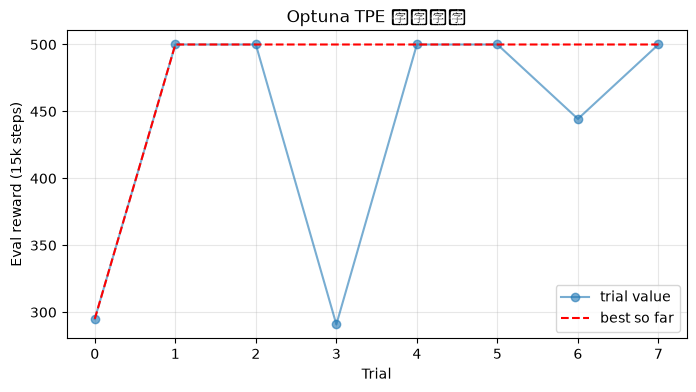

In [4]:
# 画「试验序号-分数」曲线：看 TPE 是否越调越好
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
values = df["value"].to_numpy()
ax.plot(df["number"], values, "o-", alpha=0.6, label="trial value")
ax.plot(df["number"], np.maximum.accumulate(values), "r--", label="best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Eval reward (15k steps)")
ax.set_title("Optuna TPE 搜索过程")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


> 只有 8 次试验，TPE 的「智能」还体现不明显（它需要一些随机探索打底）；调参的真实经验法则是：**预算允许的话，trials 数至少是超参个数的 10 倍**。这里的重点是跑通流程。

## 3. RL Baselines3 Zoo：站在别人调好的肩膀上

[RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) 是 SB3 官方的「超参仓库 + 训练框架」：核心团队为每个算法 × 每个经典环境用 Optuna 做了大规模调参（每个任务数百次试验），结果存在 `hyperparams/<algo>.yml` 里。

**工程启示**：在经典环境上，先用 Zoo 的超参做 baseline，比自己从零调参快一个数量级。自己调参只花在「Zoo 没覆盖的自定义环境」上——比如我们的 `DroneHoverEnv`。

Zoo 的 yml 里有两个约定要会读：

- `learning_rate: lin_0.001` —— `lin_` 前缀表示**线性衰减 schedule**：从 0.001 线性降到 0，而不是常数；
- 网络结构写作 `net_arch: [64, 64]` 之类，在 SB3 里通过 `policy_kwargs=dict(net_arch=[...])` 传入。

下面把 Zoo 为 CartPole-v1 调好的 PPO 超参（`hyperparams/ppo.yml`，v2.x 版本）与 SB3 默认超参做公平对比——同一训练预算、同一评估协议：


In [5]:
from stable_baselines3.common.callbacks import EvalCallback

from robot_rl_learn.common.paths import make_run_dir


def linear_schedule(initial_value: float):
    """学习率线性衰减 schedule：从 initial_value 随训练进度线性降到 0。

    SB3 2.9 移除了旧版 utils.linear_schedule，这里给出等价实现
    （SB3 的 schedule 协议：输入剩余进度 progress_remaining∈[0,1]，输出当前值）。
    """
    def f(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return f


# RL Baselines3 Zoo, hyperparams/ppo.yml 中 CartPole-v1 的官方调参结果
zoo_params = dict(
    n_steps=32,
    batch_size=256,
    gae_lambda=0.8,
    gamma=0.98,
    n_epochs=20,
    ent_coef=0.0,
    learning_rate=linear_schedule(0.001),  # yml 中的 lin_0.001
    clip_range=linear_schedule(0.2),       # yml 中的 lin_0.2
)

TOTAL_STEPS = 30_000
results = {}

for name, kwargs in [("SB3 默认", {}), ("Zoo 官方", zoo_params)]:
    run_dir = make_run_dir(f"w08_{'default' if name == 'SB3 默认' else 'zoo'}")
    env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor)
    eval_env = Monitor(gym.make("CartPole-v1"))
    eval_cb = EvalCallback(eval_env, eval_freq=2_000, log_path=str(run_dir / "eval"), verbose=0)
    model = PPO("MlpPolicy", env, seed=0, verbose=0, **kwargs)
    model.learn(total_timesteps=TOTAL_STEPS, callback=eval_cb)
    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
    results[name] = (mean_r, std_r)
    print(f"{name}: {mean_r:.1f} ± {std_r:.1f}")
    env.close()


SB3 默认: 369.0 ± 105.5


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=32 and n_envs=4)
  warnings.warn(


Zoo 官方: 500.0 ± 0.0


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 40664 (\N{CJK UNIFIED IDEOGRAPH-9ED8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35748 (\N{CJK UNIFIED IDEOGRAPH-8BA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36229 (\N{CJK UNIFIED IDEOGRAPH-8D85}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py

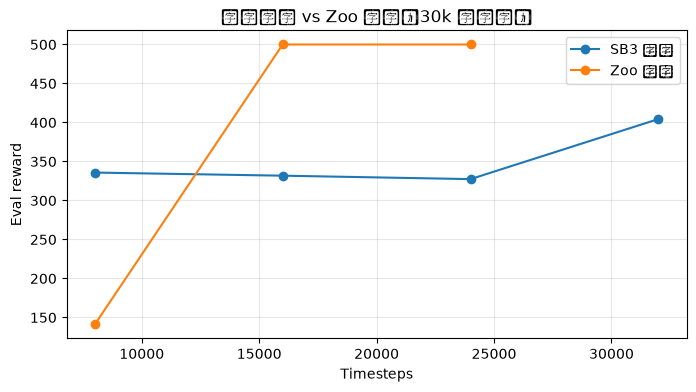

In [6]:
# 对比两组的评估曲线
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
for name, tag in [("SB3 默认", "default"), ("Zoo 官方", "zoo")]:
    d = np.load(make_run_dir(f"w08_{tag}") / "eval" / "evaluations.npz")
    ax.plot(d["timesteps"], d["results"].mean(axis=1), marker="o", label=name)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Eval reward")
ax.set_title(f"默认超参 vs Zoo 超参（{TOTAL_STEPS // 1000}k 步预算）")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


> 注意一个有趣的现象：Zoo 超参是为 **100k 步**预算调的，在 30k 短预算下未必占优——这提醒我们**超参与训练预算是耦合的**，Zoo 页面也明确写了每个配置对应的 `n_timesteps`。

## 4. 调参实验规范（中级工程师的checklist）

1. **评估协议固定**：所有 trial 用同一评估环境构造、同一 episode 数、同一种子策略；改协议 = 全部重来。
2. **粗筛 → 精调两阶段**：先用短预算淘掉明显差的组合，再对 Top-3 用完整预算 + 多种子复验。直接用粗筛分数当最终结论是大坑（短训练下大 batch 占优，长训练下未必）。
3. **记录一切**：搜索空间、每个 trial 的超参与分数、最终选择的理由。Optuna 的 `study.trials_dataframe()` 可以直接存成 CSV 进实验报告。
4. **区分调参集与最终评估**：在 CartPole 上调出的超参，报告时要说清「超参是在 CartPole 15k 步预算下调的」，避免隐性的过拟合到评估协议。
5. **先查 Zoo 再动手**：经典环境直接用 Zoo 超参当 baseline，把调参预算留给自定义环境。


## ✏️ 练习

### 练习 1（★，约 15 分钟）：为什么数量级参数要用 log 采样
用 Optuna 分别从 `suggest_float("lr", 1e-5, 1e-1, log=True)` 和 `log=False` 各采样 1000 次，画两张直方图对比，并用 3~5 句话解释：为什么 `learning_rate`、`ent_coef` 这类参数必须 log 均匀采样？
**可交付物**：对比直方图 + 文字解释。

### 练习 2（★★，约 25 分钟）：给 SAC 写调参目标函数
仿照第 2 节，为 SAC 在 `Pendulum-v1` 上写一个 Optuna objective：搜索 `learning_rate`（log，1e-4~1e-2）、`batch_size`（[128, 256, 512]）、`tau`（0.005~0.05）、`gamma`（0.9~0.999），每个 trial 训练 10k 步、评估 5 episode，跑 6 个 trials。
**可交付物**：可运行的 objective 代码 + best_params 输出 + 与 SAC 默认超参的对比数字。

### 练习 3（★★，约 20 分钟）：schedule 消融
第 3 节 Zoo 超参中 `learning_rate=linear_schedule(0.001)`。把它改成常数 `0.001`，其余不变，在同样 30k 预算下训练并画对比曲线。
**可交付物**：两条评估曲线 + 2~3 句结论（线性衰减在这个任务上有没有用？为什么）。

### 练习 4（★★★，约 30 分钟）：两阶段调参
实现「粗筛 → 精调」：阶段一用 15k 步预算跑 12 个 trials；阶段二把 Top-3 组合用 60k 步重新训练、各评估 20 个 episode。对比「粗筛第 1 名」和「精调后第 1 名」是不是同一组超参。
**可交付物**：两张表（粗筛 12 行 / 精调 3 行）+ 结论：如果名次发生变化，说明什么？


## 参考答案

### 练习 1

<details>
<summary>参考答案</summary>

```python
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
log_samples = 10 ** rng.uniform(-5, -1, 1000)      # 等价于 suggest_float(..., log=True)
lin_samples = rng.uniform(1e-5, 1e-1, 1000)        # 等价于 log=False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, samples, name in zip(axes, [log_samples, lin_samples], ["log 采样", "线性采样"]):
    ax.hist(samples, bins=50)
    ax.set_xscale("log")
    ax.set_title(name)
plt.show()
```

解释要点：学习率的有效探索范围跨越 4 个数量级，且「1e-3 到 1e-2」与「1e-4 到 1e-3」的差异同样重要（都是 10 倍变化）。线性采样会让 99% 的样本挤在 1e-2~1e-1 区间，几乎采不到小学习率；log 采样让每个数量级获得相同采样密度。
</details>

### 练习 2

<details>
<summary>参考答案</summary>

```python
import gymnasium as gym
import optuna
from stable_baselines3 import SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor


def objective_sac(trial):
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    tau = trial.suggest_float("tau", 0.005, 0.05)
    gamma = trial.suggest_float("gamma", 0.9, 0.999)

    env = Monitor(gym.make("Pendulum-v1"))
    model = SAC("MlpPolicy", env, seed=0, verbose=0,
                learning_rate=lr, batch_size=batch_size, tau=tau, gamma=gamma,
                learning_starts=200)
    model.learn(total_timesteps=10_000)
    mean_r, _ = evaluate_policy(model, Monitor(gym.make("Pendulum-v1")),
                                n_eval_episodes=5, deterministic=True)
    return mean_r


study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective_sac, n_trials=6)
print(study.best_params, study.best_value)
```

（Pendulum 的回报为负数，越接近 0 越好；6 trials 只够演示流程，实际调 SAC 至少要几十次。）
</details>

### 练习 3

<details>
<summary>参考答案</summary>

```python
# 与第 3 节相同的流程，只把 learning_rate 换成常数
const_params = dict(zoo_params, learning_rate=0.001, clip_range=0.2)
```

典型观察：在 30k 短预算内，常数 lr 与线性衰减差距不大，甚至常数略好（线性衰减在小步数时过早降低学习率）；Zoo 用衰减是因为它按 100k 预算调参，训练后期需要更小的步长稳定收敛。结论要写清「结论依赖于训练预算」。
</details>

### 练习 4

<details>
<summary>参考答案</summary>

```python
import pandas as pd

# 阶段一：粗筛（复用第 2 节 objective，n_trials=12）
study2 = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=1))
study2.optimize(objective, n_trials=12)
top3 = sorted(study2.trials, key=lambda t: t.value, reverse=True)[:3]

# 阶段二：精调，60k 步 + 20 episodes
rows = []
for t in top3:
    p = t.params
    env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor)
    model = PPO("MlpPolicy", env, seed=0, verbose=0,
                learning_rate=p["learning_rate"], n_steps=p["n_steps"],
                batch_size=p["batch_size"], gae_lambda=p["gae_lambda"],
                ent_coef=p["ent_coef"])
    model.learn(total_timesteps=60_000)
    mean_r, std_r = evaluate_policy(model, Monitor(gym.make("CartPole-v1")),
                                    n_eval_episodes=20, deterministic=True)
    rows.append({"粗筛名次": top3.index(t) + 1, "粗筛分": t.value,
                 "精调分": mean_r, **p})
    env.close()

print(pd.DataFrame(rows).round(4))
```

结论模板：粗筛名次与精调名次经常不一致，因为短预算偏好「学得快」的超参（大 lr、小 n_steps），长预算偏好「收敛稳」的超参。所以粗筛分数只能用于淘汰，不能用于排序定案。
</details>


## 延伸阅读

- [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) —— 官方超参仓库，`hyperparams/*.yml` 是本周最重要的阅读材料
- [Optuna 官方文档](https://optuna.readthedocs.io/) —— TPE sampler、pruning、可视化
- [Bergstra & Bengio, Random Search for Hyper-Parameter Optimization (JMLR 2012)](https://www.jmlr.org/papers/v13/bergstra12a.html) —— 随机搜索优于网格搜索的经典论证
- [Engstrom et al., Implementation Matters in Deep RL (ICLR 2020)](https://arxiv.org/abs/2005.12729) —— 超参与代码细节如何改变 PPO 的表现，理解「为什么调参这么重要」
- [SB3 文档：Hyperparameter Tuning](https://stable-baselines3.readthedocs.io/en/master/guide/rl_zoo.html) —— SB3 自带的 zoo 集成说明
